# Week 5 — ATNF Pulsar Catalog (HEASARC CSV)

This notebook loads **`atnf_pulsar_heasarc.csv`** (HEASARC ATNF / `atnfpulsar` dump) and walks through the usual first-look questions with **pandas**.

**Run the notebook from the `Week 5` folder** so the relative path to the CSV works.

## Setup

**What question does this answer?**  
Do we have the libraries we need, and a working pandas import?

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
print("pandas:", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


pandas: 2.3.3


**What does your dataset look like? `head()`, `info()`**  
We load the CSV into a DataFrame called `pulsars`, print the first rows, then ask pandas for column dtypes and how many non-null values each column has.

In [2]:
pulsars = pd.read_csv("atnf_pulsar_heasarc.csv")
print(pulsars.head())
print()
pulsars.info()

             name      alt_name ref_names          ra      ra_error  ref_ra  \
0  PSR J1036-8317           NaN    ckr+15  159.169129  1.300000e-07  sbf+24   
1  PSR J0211-8159           NaN    lml+98   32.995833  1.300000e-03  dsb+98   
2  PSR J1900-7951  PSR B1851-79    mlt+78  285.101667  2.100000e-03   nmc81   
3  PSR J1119-7936  PSR B1118-79    mlt+78  169.916592  5.000000e-05  kjk+24   
4  PSR J1057-7914  PSR B1056-78    mlt+78  164.363353  1.800000e-04  kjk+24   

         dec     dec_error ref_dec  pm_ra  ...         e_dot      e_dot_d2  \
0 -83.298928  1.100000e-08  sbf+24 -11.35  ...           NaN           NaN   
1 -81.993389  8.300000e-05  dsb+98    NaN  ...  8.400000e+29  3.000000e+29   
2 -79.863389  3.300000e-04   nmc81    NaN  ...  3.500000e+31  6.200000e+30   
3 -79.608264  8.300000e-06  kjk+24    NaN  ...  1.200000e+31  2.100000e+31   
4 -79.239881  3.100000e-05  kjk+24    NaN  ...  2.100000e+31  1.000000e+31   

   pm_tot  pm_tot_error transverse_velocity  corr_period

**What's the distribution of your most important column?**  
For pulsars, **spin period** (`period`, in seconds) is central. Values span many orders of magnitude, so we plot **`log10(period)`** for positive periods and print `describe()` on the raw seconds.

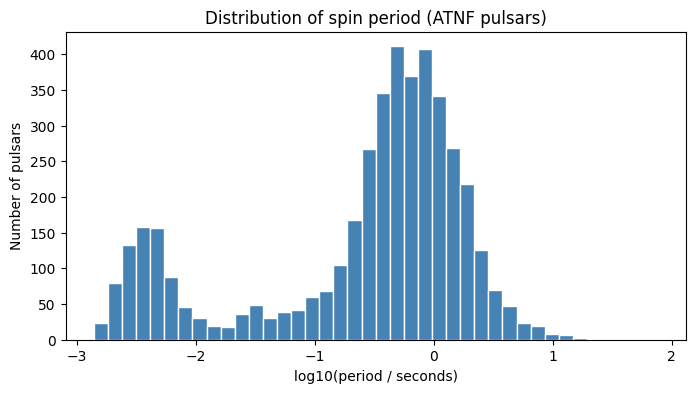

Numeric summary of period (seconds):
count    4286.000000
mean        0.857041
std         1.885271
min         0.001396
25%         0.142221
50%         0.486014
75%         1.022000
max        75.885547
Name: period, dtype: float64


In [3]:
period_s = pulsars["period"].dropna()
period_s = period_s[period_s > 0]
log_period = np.log10(period_s)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_period, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("log10(period / seconds)")
ax.set_ylabel("Number of pulsars")
ax.set_title("Distribution of spin period (ATNF pulsars)")
plt.show()

print("Numeric summary of period (seconds):")
print(pulsars["period"].describe())

**Filter to a meaningful subset. What's in it?**  
Many rows have no flux at every frequency. Here we keep only pulsars with a **measured 1400 MHz flux** (`flux_1400_mhz` not missing) and show a few useful columns.

In [4]:
with_flux = pulsars[pulsars["flux_1400_mhz"].notna()].copy()
print(f"Subset size: {len(with_flux)} rows (from {len(pulsars)} total)")
print("Sample columns from the subset:")
with_flux[["name", "pulsar_type", "dm", "flux_1400_mhz", "discovery_survey"]].head(8)

Subset size: 3031 rows (from 4351 total)
Sample columns from the subset:


,name,pulsar_type,dm,flux_1400_mhz,discovery_survey
0,PSR J1036-8317,HE,27.0927,0.450,FermiAssoc
1,PSR J0211-8159,R,24.3600,0.300,"pks70,misc"
2,PSR J1900-7951,R,39.0000,0.946,mol2
3,PSR J1119-7936,R,26.3790,0.700,"mol2,misc"
4,PSR J1057-7914,R,51.5500,0.600,"mol2,misc,pks70"
5,PSR J1159-7910,R,59.3450,0.700,"pks70,misc,pkssw"
6,PSR J1841-7845,R,41.0000,0.400,pkssw
7,PSR J1403-7646,R,101.0900,0.800,"pks70,misc,pkssw"


**Group by a category and find the average of a numeric column.**  
We group by **`pulsar_type`** and take the mean of **`dm`** (dispersion measure, pc/cm³), a standard radio-pulsar observable.

In [5]:
by_type = (
    pulsars.groupby("pulsar_type", dropna=False)["dm"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
print("Mean DM (pc/cm^3) by pulsar_type:")
print(by_type)

Mean DM (pc/cm^3) by pulsar_type:
pulsar_type
AXP,HE         868.25
AXP            699.20
R              218.09
HE             122.12
NRAD            50.35
HE,HE           36.98
AXP,NRAD          NaN
NRAD,AXP(?)       NaN
Name: dm, dtype: float64


**Where are the missing values? Are any columns incomplete?**  
We count `NaN` per column and show how many columns have gaps, plus the worst-off columns.

In [6]:
missing_per_col = pulsars.isna().sum()
cols_with_gaps = (missing_per_col > 0).sum()
print(
    f"Columns with at least one missing value: {cols_with_gaps} "
    f"(out of {pulsars.shape[1]} total columns)"
)
print("\nTop 15 columns by number of missing cells:")
print(missing_per_col.sort_values(ascending=False).head(15))

Columns with at least one missing value: 130 (out of 147 total columns)

Top 15 columns by number of missing cells:
ref_parallax           4351
flux_600_mhz_error     4351
flux_600_mhz           4351
ref_flux_3000_mhz      4351
flux_3000_mhz_error    4351
spect_index            4351
flux_3000_mhz          4351
ref_flux_1600_mhz      4351
flux_1600_mhz_error    4351
flux_1600_mhz          4351
ref_flux_900_mhz       4351
flux_900_mhz_error     4351
flux_900_mhz           4351
ref_flux_800_mhz       4351
flux_800_mhz_error     4351
dtype: int64
